# TTF Gas Supply Stack Curve — Quantitative Framework

**Merit-order supply aggregation model with interactive visualisations**

This notebook implements a full quantitative framework for building a TTF (Title Transfer Facility) gas forward price curve from fundamental supply-side drivers. It covers:

1. **Global Assumptions** — FX, carbon, coal, oil, JKM, shipping rates, demand
2. **Norwegian Pipeline Supply** — Field-by-field production, maintenance, decline curves
3. **LNG Supply** — Global liquefaction projects, Atlantic-Pacific arbitrage, European regasification
4. **Other Pipeline Imports** — Russian, Algerian, Libyan, Azerbaijani routes
5. **Indigenous EU Production** — Dutch, UKCS, Romanian, biomethane
6. **Storage Dynamics** — Inventory levels, fill targets, injection/withdrawal profiles
7. **Supply Stack Aggregation** — Merit-order ranking, clearing price derivation
8. **Scenario Analysis** — Risk scenarios, sensitivity, probability-weighted pricing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── STYLE ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0a0f1a',
    'axes.facecolor': '#0d1b2a',
    'axes.edgecolor': '#1e2a3a',
    'axes.labelcolor': '#8892b0',
    'axes.grid': True,
    'grid.color': '#1e2a3a',
    'grid.alpha': 0.6,
    'text.color': '#e0e0e0',
    'xtick.color': '#8892b0',
    'ytick.color': '#8892b0',
    'legend.facecolor': '#0d1b2a',
    'legend.edgecolor': '#1e2a3a',
    'legend.fontsize': 9,
    'font.family': 'sans-serif',
    'font.size': 10,
    'figure.dpi': 120,
})

YEARS = [2025, 2026, 2027, 2028, 2029]
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Colour palette
C = {
    'norway': '#2E75B6', 'indigenous': '#70AD47', 'russia': '#BF0000',
    'algeria': '#ED7D31', 'azerbaijan': '#FFC000', 'libya': '#A5A5A5',
    'storage': '#7030A0', 'lng': '#00B0F0', 'accent': '#ff9f43',
    'positive': '#70AD47', 'negative': '#ff6b6b', 'neutral': '#8892b0',
    'bg': '#0a0f1a', 'card': '#0d1b2a', 'border': '#1e2a3a',
}

print("✓ Environment configured")

✓ Environment configured


## 1. Global Assumptions

All key macro and cross-commodity inputs that feed into the supply-side models. Blue-highlighted values are the primary scenario levers.

In [2]:
# ── GLOBAL PARAMETERS ──────────────────────────────────────
assumptions = pd.DataFrame({
    'EUR/USD': [1.08, 1.10, 1.12, 1.12, 1.12],
    'EU ETS Carbon (EUR/tCO2)': [65, 72, 80, 88, 95],
    'API2 Coal (USD/t)': [110, 105, 100, 95, 90],
    'Brent (USD/bbl)': [78, 75, 72, 70, 70],
    'JKM (USD/MMBtu)': [12.5, 11.8, 11.0, 10.5, 10.0],
    'Shipping US→EU (USD/MMBtu)': [0.80, 0.80, 0.75, 0.75, 0.70],
    'Shipping US→Asia (USD/MMBtu)': [2.20, 2.10, 2.00, 2.00, 1.90],
    'Storage Mandate (%)': [90, 90, 90, 90, 90],
    'Storage Working Cap (bcm)': [110, 112, 114, 115, 115],
    'Total Demand (bcm)': [340, 335, 330, 325, 320],
    'Power Demand (bcm)': [95, 92, 88, 85, 82],
    'Industrial Demand (bcm)': [105, 103, 102, 100, 98],
    'Resi/Commercial (bcm)': [140, 140, 140, 140, 140],
}, index=YEARS)
assumptions.index.name = 'Year'

# Demand breakdown
demand = assumptions[['Power Demand (bcm)','Industrial Demand (bcm)','Resi/Commercial (bcm)']].copy()
demand.columns = ['Power','Industrial','Residential/Commercial']

print("Global Assumptions")
print("="*80)
display(assumptions.T.style.format('{:.1f}').set_properties(**{'text-align':'right'}))

Global Assumptions


Year,2025,2026,2027,2028,2029
EUR/USD,1.1,1.1,1.1,1.1,1.1
EU ETS Carbon (EUR/tCO2),65.0,72.0,80.0,88.0,95.0
API2 Coal (USD/t),110.0,105.0,100.0,95.0,90.0
Brent (USD/bbl),78.0,75.0,72.0,70.0,70.0
JKM (USD/MMBtu),12.5,11.8,11.0,10.5,10.0
Shipping US→EU (USD/MMBtu),0.8,0.8,0.8,0.8,0.7
Shipping US→Asia (USD/MMBtu),2.2,2.1,2.0,2.0,1.9
Storage Mandate (%),90.0,90.0,90.0,90.0,90.0
Storage Working Cap (bcm),110.0,112.0,114.0,115.0,115.0
Total Demand (bcm),340.0,335.0,330.0,325.0,320.0


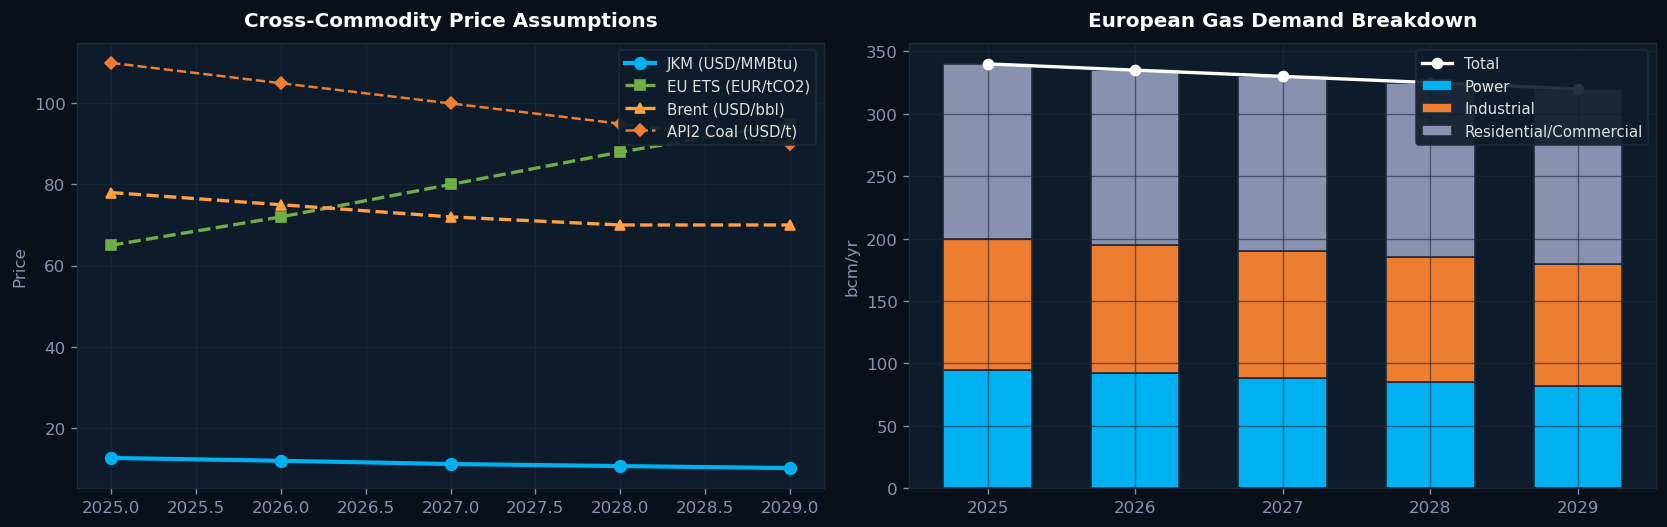

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Cross-commodity price trends
ax1.plot(YEARS, assumptions['JKM (USD/MMBtu)'], 'o-', color=C['lng'], lw=2.5, ms=7, label='JKM (USD/MMBtu)')
ax1.plot(YEARS, assumptions['EU ETS Carbon (EUR/tCO2)'], 's--', color=C['positive'], lw=2, ms=6, label='EU ETS (EUR/tCO2)')
ax1.plot(YEARS, assumptions['Brent (USD/bbl)'], '^--', color=C['accent'], lw=2, ms=6, label='Brent (USD/bbl)')
ax1.plot(YEARS, assumptions['API2 Coal (USD/t)'], 'D--', color=C['algeria'], lw=1.5, ms=5, label='API2 Coal (USD/t)')
ax1.set_title('Cross-Commodity Price Assumptions', fontsize=12, fontweight='bold', color='white', pad=10)
ax1.legend(loc='upper right', framealpha=0.9)
ax1.set_ylabel('Price')

# Demand breakdown
bottom = np.zeros(5)
colors_d = [C['lng'], C['algeria'], C['neutral']]
for i, col in enumerate(demand.columns):
    ax2.bar(YEARS, demand[col], bottom=bottom, color=colors_d[i], label=col, width=0.6, edgecolor='#1e2a3a')
    bottom += demand[col].values
ax2.plot(YEARS, assumptions['Total Demand (bcm)'], 'wo-', ms=6, lw=2, label='Total', zorder=5)
ax2.set_title('European Gas Demand Breakdown', fontsize=12, fontweight='bold', color='white', pad=10)
ax2.set_ylabel('bcm/yr')
ax2.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()

## 2. Norwegian Pipeline Supply Model

Field-by-field production capacity with maintenance deductions and processing constraints. Norway is Europe's largest single source (~30% of supply) and the lowest marginal cost producer on the stack.

In [4]:
# ── NORWEGIAN FIELD DATA ───────────────────────────────────
norway_fields = pd.DataFrame({
    'Troll':        [36.0, 35.5, 35.0, 34.5, 34.0],
    'Ormen Lange':  [14.0, 13.5, 13.0, 12.5, 12.0],
    'Åsgard':       [7.5, 7.2, 6.9, 6.6, 6.3],
    'Kristin':      [3.5, 3.3, 3.1, 2.9, 2.7],
    'Kvitebjørn':   [5.0, 4.8, 4.6, 4.4, 4.2],
    'Skarv':        [4.0, 3.8, 3.6, 3.4, 3.2],
    'Gjøa':         [2.5, 2.3, 2.1, 2.0, 1.9],
    'Other fields': [20.0, 19.0, 18.0, 17.0, 16.0],
}, index=YEARS)

decline_rates = {'Troll': 2.8, 'Ormen Lange': 3.5, 'Åsgard': 4.0, 'Kristin': 6.0,
                 'Kvitebjørn': 4.0, 'Skarv': 5.0, 'Gjøa': 7.0, 'Other fields': 5.0}

norway_deductions = pd.DataFrame({
    'Planned Maintenance': [8.0, 8.5, 9.0, 9.5, 10.0],
    'Unplanned Outage':    [3.0, 3.0, 3.0, 3.0, 3.0],
    'Processing Constraint':[1.5, 1.5, 1.5, 1.5, 1.5],
}, index=YEARS)

norway_marginal_cost = [6.0, 6.2, 6.4, 6.6, 6.8]  # EUR/MWh

# Calculations
norway_gross = norway_fields.sum(axis=1)
norway_total_ded = norway_deductions.sum(axis=1)
norway_net = norway_gross - norway_total_ded

norway_summary = pd.DataFrame({
    'Gross Capacity': norway_gross,
    'Total Deductions': norway_total_ded,
    'Net Deliverable': norway_net,
    'Marginal Cost (EUR/MWh)': norway_marginal_cost,
}, index=YEARS)

print("Norwegian Supply Summary (bcm/yr)")
print("="*60)
display(norway_summary.style.format('{:.1f}'))

Norwegian Supply Summary (bcm/yr)


,Gross Capacity,Total Deductions,Net Deliverable,Marginal Cost (EUR/MWh)
2025,92.5,12.5,80.0,6.0
2026,89.4,13.0,76.4,6.2
2027,86.3,13.5,72.8,6.4
2028,83.3,14.0,69.3,6.6
2029,80.3,14.5,65.8,6.8


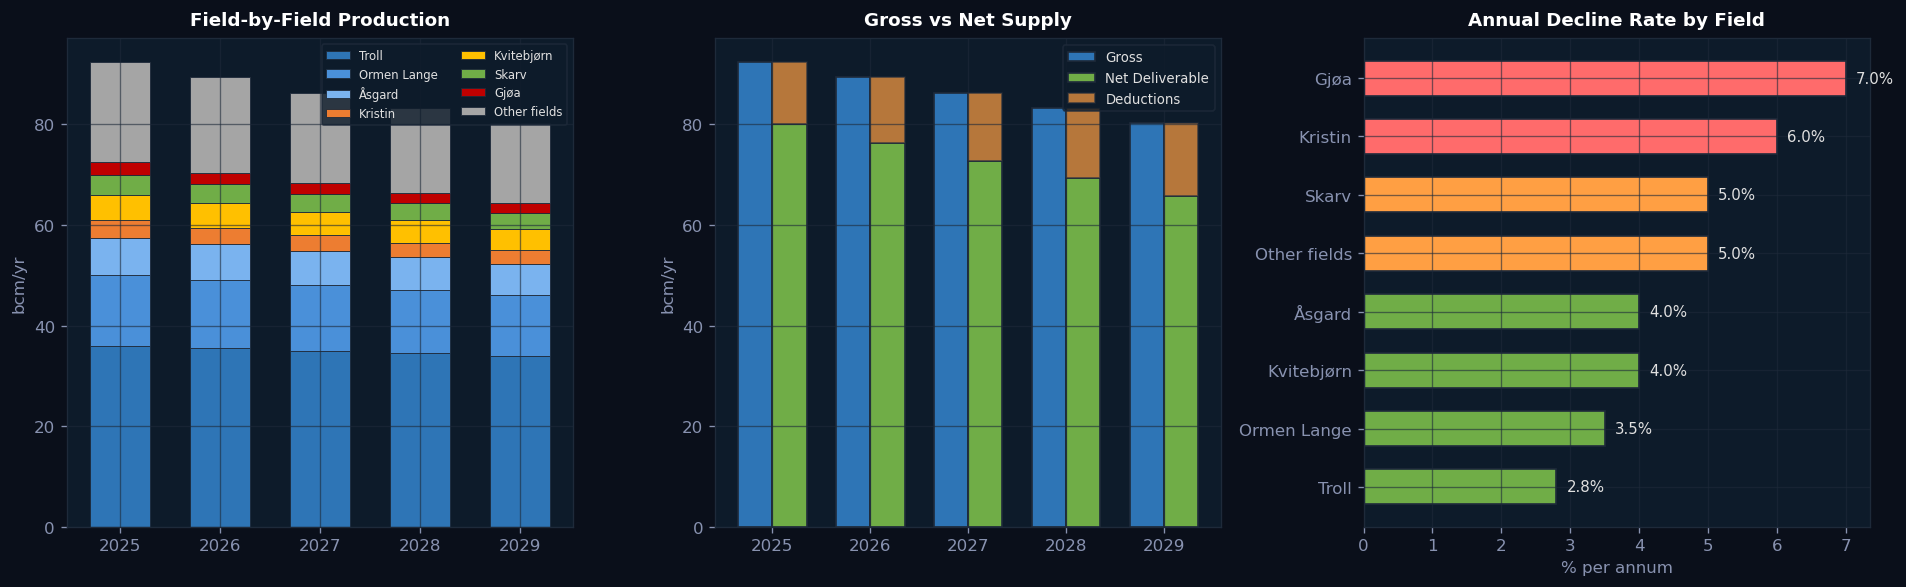

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Field production stacked bar
ax = axes[0]
field_colors = ['#2E75B6','#4a90d9','#7ab3ef','#ED7D31','#FFC000','#70AD47','#BF0000','#A5A5A5']
bottom = np.zeros(5)
for i, col in enumerate(norway_fields.columns):
    ax.bar(YEARS, norway_fields[col], bottom=bottom, color=field_colors[i],
           label=col, width=0.6, edgecolor='#1e2a3a', linewidth=0.5)
    bottom += norway_fields[col].values
ax.set_title('Field-by-Field Production', fontsize=11, fontweight='bold', color='white', pad=8)
ax.set_ylabel('bcm/yr')
ax.legend(fontsize=7, loc='upper right', ncol=2)

# Gross vs Net
ax = axes[1]
x = np.arange(5)
w = 0.35
ax.bar(x - w/2, norway_gross, w, color=C['norway'], label='Gross', edgecolor='#1e2a3a')
ax.bar(x + w/2, norway_net, w, color=C['positive'], label='Net Deliverable', edgecolor='#1e2a3a')
ax.bar(x + w/2, norway_total_ded, w, bottom=norway_net, color=C['accent'],
       label='Deductions', edgecolor='#1e2a3a', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(YEARS)
ax.set_title('Gross vs Net Supply', fontsize=11, fontweight='bold', color='white', pad=8)
ax.set_ylabel('bcm/yr')
ax.legend(fontsize=8)

# Decline rates
ax = axes[2]
fields_sorted = sorted(decline_rates.items(), key=lambda x: x[1], reverse=True)
names, rates = zip(*fields_sorted)
colors_dr = [C['negative'] if r > 5 else C['accent'] if r > 4 else C['positive'] for r in rates]
bars = ax.barh(names, rates, color=colors_dr, edgecolor='#1e2a3a', height=0.6)
for bar, rate in zip(bars, rates):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
            f'{rate:.1f}%', va='center', fontsize=9, color='#e0e0e0')
ax.set_title('Annual Decline Rate by Field', fontsize=11, fontweight='bold', color='white', pad=8)
ax.set_xlabel('% per annum')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 3. LNG Supply Model

Global liquefaction capacity by project, Atlantic-Pacific arbitrage allocation to Europe, and European regasification terminal utilisation. LNG is the **marginal supply source** — the price at which Europe attracts enough cargoes to balance sets the TTF clearing price.

In [ ]:
# ── GLOBAL LNG PROJECTS ────────────────────────────────────
lng_projects = pd.DataFrame({
    'Sabine Pass T1-6':       [28.5, 28.5, 28.5, 28.5, 28.5],
    'Cameron T1-3':           [13.5, 13.5, 13.5, 13.5, 13.5],
    'Freeport T1-3':          [13.5, 13.5, 13.5, 13.5, 13.5],
    'Corpus Christi + SPL':   [20.0, 22.0, 25.0, 25.0, 25.0],
    'Plaquemines P1-P2':      [5.0, 12.0, 18.0, 20.0, 20.0],
    'Golden Pass T1-3':       [0.0, 4.0, 12.0, 16.0, 18.0],
    'Other US (FID wave)':    [0.0, 0.0, 0.0, 5.0, 12.0],
    'Qatar NFE':              [0.0, 8.0, 20.0, 32.0, 32.0],
    'Qatar NFS':              [0.0, 0.0, 0.0, 4.0, 12.0],
    'Existing Qatar':         [77.0, 77.0, 77.0, 77.0, 77.0],
    'Gorgon T1-3':            [14.0, 14.0, 13.5, 13.5, 13.0],
    'AU NWS/Wheat/Ichthys':   [36.0, 35.5, 35.0, 34.5, 34.0],
    'Nigeria LNG + T7':       [22.0, 22.0, 25.0, 28.0, 30.0],
    'Angola/Cameroon/EG':     [7.5, 7.5, 7.5, 7.5, 7.5],
    'Yamal + Arctic LNG 2':   [20.0, 22.0, 24.0, 26.0, 28.0],
    'Coral FLNG / Rovuma':    [3.4, 3.4, 3.4, 3.4, 5.0],
    'Greater Tortue FLNG':    [0.5, 2.0, 2.5, 2.5, 2.5],
    'Other (Trinidad etc)':   [22.0, 22.0, 22.0, 22.0, 22.0],
}, index=YEARS)

lng_country_map = {
    'Sabine Pass T1-6': 'US', 'Cameron T1-3': 'US', 'Freeport T1-3': 'US',
    'Corpus Christi + SPL': 'US', 'Plaquemines P1-P2': 'US', 'Golden Pass T1-3': 'US',
    'Other US (FID wave)': 'US', 'Qatar NFE': 'Qatar', 'Qatar NFS': 'Qatar',
    'Existing Qatar': 'Qatar', 'Gorgon T1-3': 'Australia', 'AU NWS/Wheat/Ichthys': 'Australia',
    'Nigeria LNG + T7': 'Nigeria', 'Angola/Cameroon/EG': 'W.Africa',
    'Yamal + Arctic LNG 2': 'Russia', 'Coral FLNG / Rovuma': 'Mozambique',
    'Greater Tortue FLNG': 'Mauritania', 'Other (Trinidad etc)': 'Other',
}

# Aggregation
lng_global_supply = lng_projects.sum(axis=1)  # MTPA
lng_demand_ex_europe = pd.Series([210, 230, 260, 290, 315], index=YEARS)
MTPA_TO_BCM = 1.379

lng_available_mtpa = (lng_global_supply - lng_demand_ex_europe).clip(lower=0)
lng_available_bcm = lng_available_mtpa * MTPA_TO_BCM

eu_regas_capacity = pd.Series([220, 230, 235, 240, 240], index=YEARS)
eu_regas_util_cap = 0.85
lng_max_deliverable = pd.DataFrame({
    'Available': lng_available_bcm,
    'Regas Limit': eu_regas_capacity * eu_regas_util_cap,
}).min(axis=1)

lng_marginal_cost = [32.0, 30.0, 28.0, 26.0, 25.0]  # EUR/MWh

# By country
lng_by_country = pd.DataFrame(index=YEARS)
for proj, country in lng_country_map.items():
    if country not in lng_by_country.columns:
        lng_by_country[country] = 0
    lng_by_country[country] += lng_projects[proj]

print("LNG Supply Summary")
print("="*60)
lng_summary = pd.DataFrame({
    'Global Supply (MTPA)': lng_global_supply,
    'Ex-Europe Demand (MTPA)': lng_demand_ex_europe,
    'Available for EU (MTPA)': lng_available_mtpa,
    'Available for EU (bcm)': lng_available_bcm,
    'Max Deliverable (bcm)': lng_max_deliverable,
    'Marginal Cost (EUR/MWh)': lng_marginal_cost,
}, index=YEARS)
display(lng_summary.style.format('{:.1f}'))

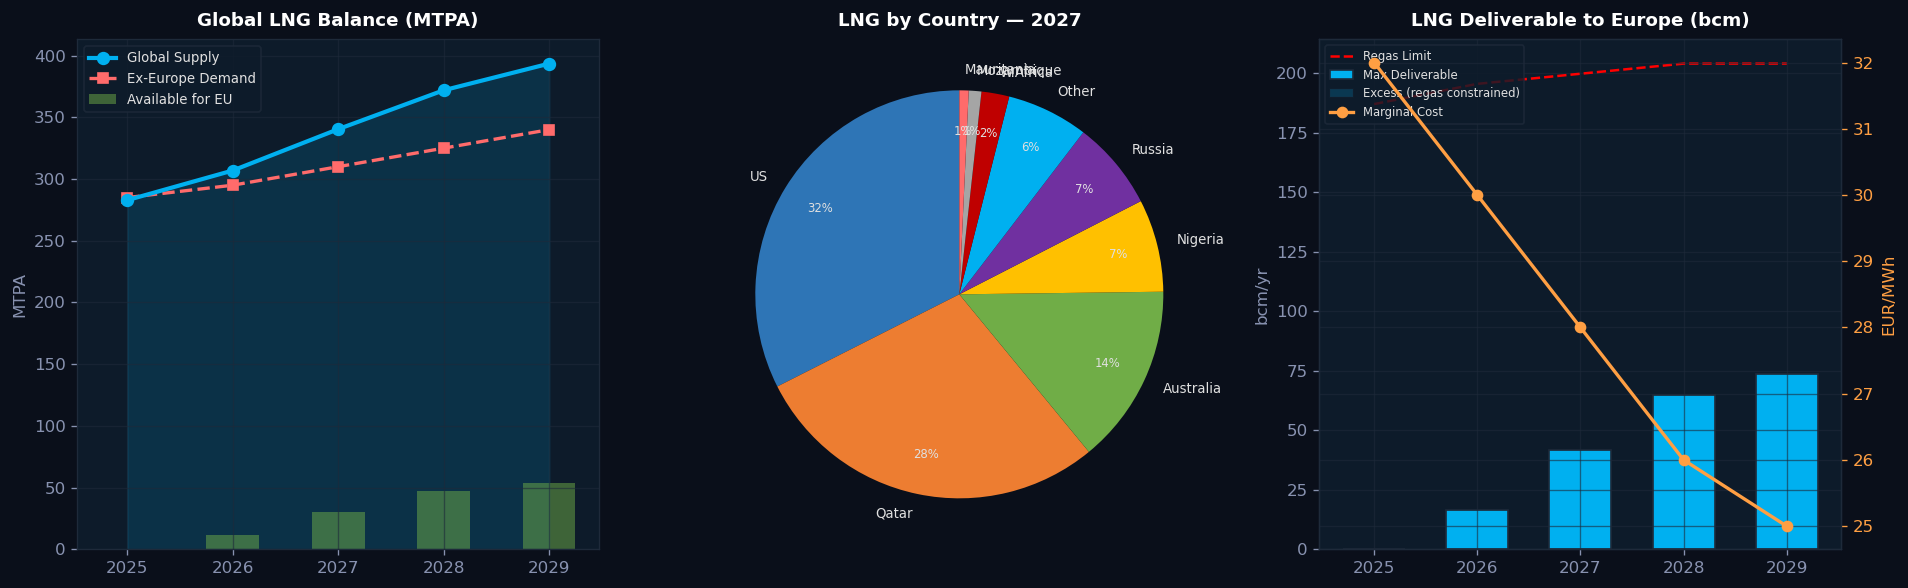

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Global supply vs demand
ax = axes[0]
ax.fill_between(YEARS, lng_global_supply, alpha=0.15, color=C['lng'])
ax.plot(YEARS, lng_global_supply, 'o-', color=C['lng'], lw=2.5, ms=7, label='Global Supply', zorder=5)
ax.plot(YEARS, lng_demand_ex_europe, 's--', color=C['negative'], lw=2, ms=6, label='Ex-Europe Demand')
ax.bar(YEARS, lng_available_mtpa, color=C['positive'], alpha=0.5, width=0.5, label='Available for EU')
ax.set_title('Global LNG Balance (MTPA)', fontsize=11, fontweight='bold', color='white', pad=8)
ax.set_ylabel('MTPA')
ax.legend(fontsize=8)

# By country pie for 2027
ax = axes[1]
yr_idx = 2  # 2027
country_vals = lng_by_country.iloc[yr_idx].sort_values(ascending=False)
pie_colors = ['#2E75B6','#ED7D31','#70AD47','#FFC000','#7030A0','#00B0F0','#BF0000','#A5A5A5','#FF6B6B']
wedges, texts, autotexts = ax.pie(country_vals, labels=country_vals.index, autopct='%1.0f%%',
    colors=pie_colors[:len(country_vals)], pctdistance=0.8, startangle=90,
    textprops={'fontsize':8, 'color':'#e0e0e0'})
for t in autotexts:
    t.set_fontsize(7)
    t.set_color('#e0e0e0')
ax.set_title(f'LNG by Country — {YEARS[yr_idx]}', fontsize=11, fontweight='bold', color='white', pad=8)

# Deliverable LNG to Europe
ax = axes[2]
ax.bar(YEARS, lng_max_deliverable, color=C['lng'], edgecolor='#1e2a3a', width=0.6, label='Max Deliverable')
ax.bar(YEARS, lng_available_bcm - lng_max_deliverable, bottom=lng_max_deliverable,
       color=C['lng'], alpha=0.2, edgecolor='#1e2a3a', width=0.6, label='Excess (regas constrained)')
ax.plot(YEARS, eu_regas_capacity * eu_regas_util_cap, 'r--', lw=1.5, label='Regas Limit')
ax2 = ax.twinx()
ax2.plot(YEARS, lng_marginal_cost, 'o-', color=C['accent'], lw=2, ms=6, label='Marginal Cost')
ax2.set_ylabel('EUR/MWh', color=C['accent'])
ax2.tick_params(axis='y', colors=C['accent'])
ax.set_title('LNG Deliverable to Europe (bcm)', fontsize=11, fontweight='bold', color='white', pad=8)
ax.set_ylabel('bcm/yr')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

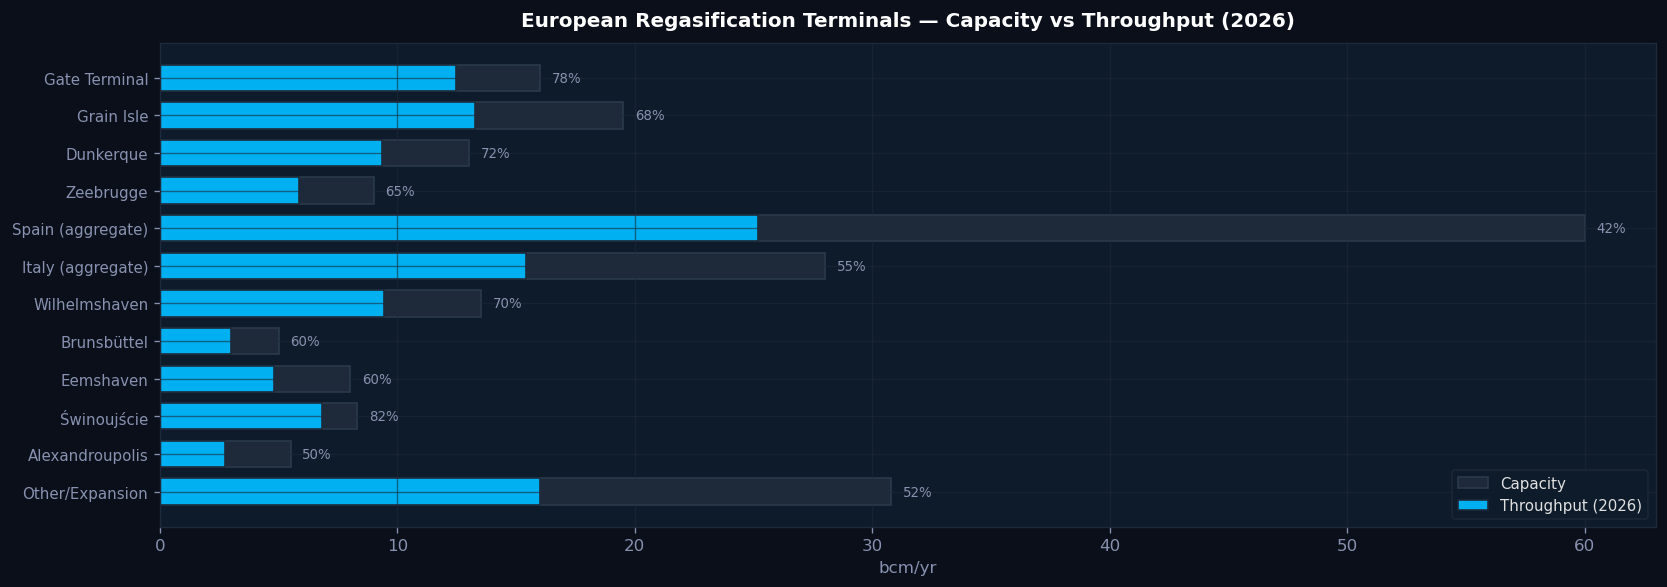

In [8]:
# ── EUROPEAN REGASIFICATION TERMINALS ──────────────────────
regas_data = {
    'Gate Terminal': (16.0, 'NL', [0.75,0.78,0.80,0.80,0.80]),
    'Grain Isle': (19.5, 'UK', [0.65,0.68,0.70,0.72,0.72]),
    'Dunkerque': (13.0, 'FR', [0.70,0.72,0.75,0.75,0.75]),
    'Zeebrugge': (9.0, 'BE', [0.60,0.65,0.68,0.70,0.70]),
    'Spain (aggregate)': (60.0, 'ES', [0.40,0.42,0.45,0.48,0.50]),
    'Italy (aggregate)': (28.0, 'IT', [0.50,0.55,0.58,0.60,0.62]),
    'Wilhelmshaven': (13.5, 'DE', [0.60,0.70,0.75,0.80,0.85]),
    'Brunsbüttel': (5.0, 'DE', [0.50,0.60,0.70,0.75,0.80]),
    'Eemshaven': (8.0, 'NL', [0.55,0.60,0.65,0.68,0.70]),
    'Świnoujście': (8.3, 'PL', [0.80,0.82,0.85,0.85,0.85]),
    'Alexandroupolis': (5.5, 'GR', [0.30,0.50,0.60,0.65,0.70]),
    'Other/Expansion': (30.8, 'Various', [0.45,0.52,0.58,0.62,0.65]),
}

regas_names = list(regas_data.keys())
regas_caps = [v[0] for v in regas_data.values()]
regas_util_2026 = [v[2][1] for v in regas_data.values()]
regas_throughput = [c*u for c,u in zip(regas_caps, regas_util_2026)]

fig, ax = plt.subplots(figsize=(14, 5))
y = np.arange(len(regas_names))
ax.barh(y, regas_caps, color='#1e2a3a', edgecolor='#2a3a4a', height=0.7, label='Capacity')
ax.barh(y, regas_throughput, color=C['lng'], edgecolor='#1e2a3a', height=0.7, label='Throughput (2026)')
for i, (cap, thr, util) in enumerate(zip(regas_caps, regas_throughput, regas_util_2026)):
    ax.text(cap + 0.5, i, f'{util:.0%}', va='center', fontsize=8, color=C['neutral'])
ax.set_yticks(y)
ax.set_yticklabels(regas_names, fontsize=9)
ax.set_xlabel('bcm/yr')
ax.set_title('European Regasification Terminals — Capacity vs Throughput (2026)',
             fontsize=12, fontweight='bold', color='white', pad=10)
ax.legend(loc='lower right', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Other Pipeline Imports & Indigenous EU Production

Covers Russian (TurkStream), North African (Transmed, Medgaz, Greenstream), and Azerbaijani (TAP/TANAP) pipeline routes, plus declining indigenous EU production and growing biomethane.

In [9]:
# ── PIPELINE IMPORTS ───────────────────────────────────────
pipeline_routes = pd.DataFrame({
    'TurkStream (Russia)':     [12.0, 10.0, 8.0, 6.0, 5.0],
    'Ukraine Transit (Russia)':[0.0, 0.0, 0.0, 0.0, 0.0],
    'Transmed (Algeria)':      [22.0, 21.0, 20.0, 19.0, 18.0],
    'Medgaz (Algeria)':        [8.0, 8.0, 8.0, 7.5, 7.5],
    'Greenstream (Libya)':     [3.0, 3.0, 3.0, 3.0, 3.0],
    'TAP/TANAP (Azerbaijan)':  [10.0, 10.0, 10.0, 10.0, 12.0],
}, index=YEARS)

pipeline_by_source = pd.DataFrame({
    'Russia':     [12.0, 10.0, 8.0, 6.0, 5.0],
    'Algeria':    [30.0, 29.0, 28.0, 26.5, 25.5],
    'Libya':      [3.0, 3.0, 3.0, 3.0, 3.0],
    'Azerbaijan': [10.0, 10.0, 10.0, 10.0, 12.0],
}, index=YEARS)
pipeline_total = pipeline_by_source.sum(axis=1)

pipeline_costs = {
    'Russia': [20.0]*5, 'Algeria': [22.0,21.0,20.0,19.5,19.0],
    'Libya': [22.0]*5, 'Azerbaijan': [24.0,23.5,23.0,22.5,22.0],
}

# ── INDIGENOUS EU PRODUCTION ──────────────────────────────
indigenous = pd.DataFrame({
    'Dutch small fields':  [4.5, 3.8, 3.2, 2.7, 2.3],
    'UKCS':                [35.0, 33.0, 31.0, 29.0, 27.0],
    'Romania (Neptun Deep)':[5.5, 5.5, 5.5, 8.0, 10.0],
    'Denmark/Poland/Other': [3.0, 2.8, 2.6, 2.4, 2.2],
    'Biomethane / RNG':     [3.5, 4.5, 5.5, 7.0, 9.0],
}, index=YEARS)
indigenous_total = indigenous.sum(axis=1)
indigenous_cost = [8.0, 8.5, 9.0, 9.5, 10.0]

print("Pipeline Imports by Source (bcm/yr)")
display(pipeline_by_source.style.format('{:.1f}'))
print("\nIndigenous EU Production (bcm/yr)")
display(indigenous.style.format('{:.1f}'))

Pipeline Imports by Source (bcm/yr)


,Russia,Algeria,Libya,Azerbaijan
2025,12.0,30.0,3.0,10.0
2026,10.0,29.0,3.0,10.0
2027,8.0,28.0,3.0,10.0
2028,6.0,26.5,3.0,10.0
2029,5.0,25.5,3.0,12.0



Indigenous EU Production (bcm/yr)


,Dutch small fields,UKCS,Romania (Neptun Deep),Denmark/Poland/Other,Biomethane / RNG
2025,4.5,35.0,5.5,3.0,3.5
2026,3.8,33.0,5.5,2.8,4.5
2027,3.2,31.0,5.5,2.6,5.5
2028,2.7,29.0,8.0,2.4,7.0
2029,2.3,27.0,10.0,2.2,9.0


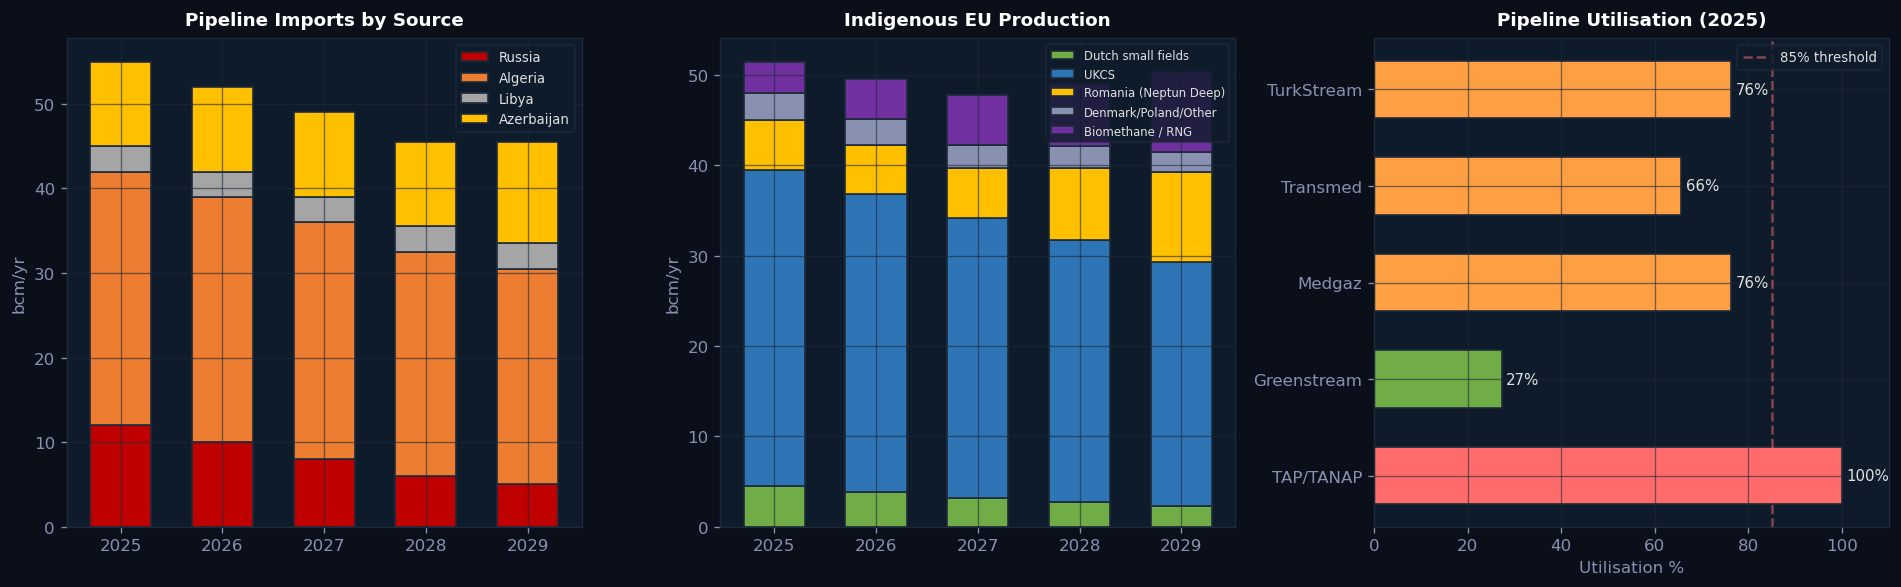

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pipeline by source
ax = axes[0]
src_colors = {'Russia': C['russia'], 'Algeria': C['algeria'], 'Libya': C['libya'], 'Azerbaijan': C['azerbaijan']}
bottom = np.zeros(5)
for col in pipeline_by_source.columns:
    ax.bar(YEARS, pipeline_by_source[col], bottom=bottom, color=src_colors[col],
           label=col, width=0.6, edgecolor='#1e2a3a')
    bottom += pipeline_by_source[col].values
ax.set_title('Pipeline Imports by Source', fontsize=11, fontweight='bold', color='white', pad=8)
ax.set_ylabel('bcm/yr')
ax.legend(fontsize=8)

# Indigenous production
ax = axes[1]
ind_colors = [C['positive'],'#2E75B6',C['azerbaijan'],C['neutral'],C['storage']]
bottom = np.zeros(5)
for i, col in enumerate(indigenous.columns):
    ax.bar(YEARS, indigenous[col], bottom=bottom, color=ind_colors[i],
           label=col, width=0.6, edgecolor='#1e2a3a')
    bottom += indigenous[col].values
ax.set_title('Indigenous EU Production', fontsize=11, fontweight='bold', color='white', pad=8)
ax.set_ylabel('bcm/yr')
ax.legend(fontsize=7, loc='upper right')

# Pipeline utilisation
ax = axes[2]
capacities = {'TurkStream': 15.75, 'Transmed': 33.5, 'Medgaz': 10.5,
              'Greenstream': 11.0, 'TAP/TANAP': 10.0}
utils = [12/15.75*100, 22/33.5*100, 8/10.5*100, 3/11*100, 10/10*100]
names_p = list(capacities.keys())
colors_u = [C['negative'] if u > 80 else C['accent'] if u > 60 else C['positive'] for u in utils]
bars = ax.barh(names_p, utils, color=colors_u, edgecolor='#1e2a3a', height=0.6)
ax.axvline(x=85, color=C['negative'], linestyle='--', alpha=0.5, label='85% threshold')
for bar, u in zip(bars, utils):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{u:.0f}%', va='center', fontsize=9, color='#e0e0e0')
ax.set_title('Pipeline Utilisation (2025)', fontsize=11, fontweight='bold', color='white', pad=8)
ax.set_xlabel('Utilisation %')
ax.set_xlim(0, 110)
ax.invert_yaxis()
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Storage Dynamics Model

EU storage is simultaneously a supply source (winter withdrawal) and demand source (summer injection). The 90% fill mandate by 1 November creates a structural injection demand that competes for molecules.

In [ ]:
# ── STORAGE MODEL ──────────────────────────────────────────
storage = pd.DataFrame({
    'Working Capacity': [110, 112, 114, 115, 115],
    'Start Inventory (1 Jan)': [75, 70, 68, 66, 65],
    'Mandate Target (%)': [90, 90, 90, 90, 90],
    'Winter Withdrawal': [55, 54, 53, 52, 51],
}, index=YEARS)

storage['Target Inventory'] = storage['Working Capacity'] * storage['Mandate Target (%)'] / 100
storage['Required Injection'] = storage['Target Inventory'] - storage['Start Inventory (1 Jan)']
storage['End Winter Inventory'] = storage['Target Inventory'] - storage['Winter Withdrawal']
storage_cost = [28.0, 29.0, 30.0, 31.0, 32.0]

# Monthly profile (matches Python engine)
def monthly_profile(year_idx):
    start = storage['Start Inventory (1 Jan)'].iloc[year_idx]
    target = storage['Target Inventory'].iloc[year_idx]
    withdrawal = storage['Winter Withdrawal'].iloc[year_idx]
    cap = storage['Working Capacity'].iloc[year_idx]
    level = start
    monthly = []
    for m in range(12):
        if m < 3:  # Jan-Mar: withdraw
            level -= withdrawal * 0.25 / 3 * 2  # heavier early winter
        elif m < 10:  # Apr-Oct: inject
            injection_needed = target - level
            level += injection_needed / (10 - m) if m < 10 else 0
            level = min(level, cap)
        else:  # Nov-Dec: withdraw
            level -= withdrawal * 0.15
        monthly.append(round(max(0, min(level, cap)), 1))
    return monthly

storage_monthly = pd.DataFrame(
    {y: monthly_profile(i) for i, y in enumerate(YEARS)},
    index=MONTHS
)

print("Storage Dynamics Summary (bcm)")
display(storage[['Working Capacity','Start Inventory (1 Jan)','Target Inventory',
                 'Required Injection','Winter Withdrawal','End Winter Inventory']].style.format('{:.1f}'))

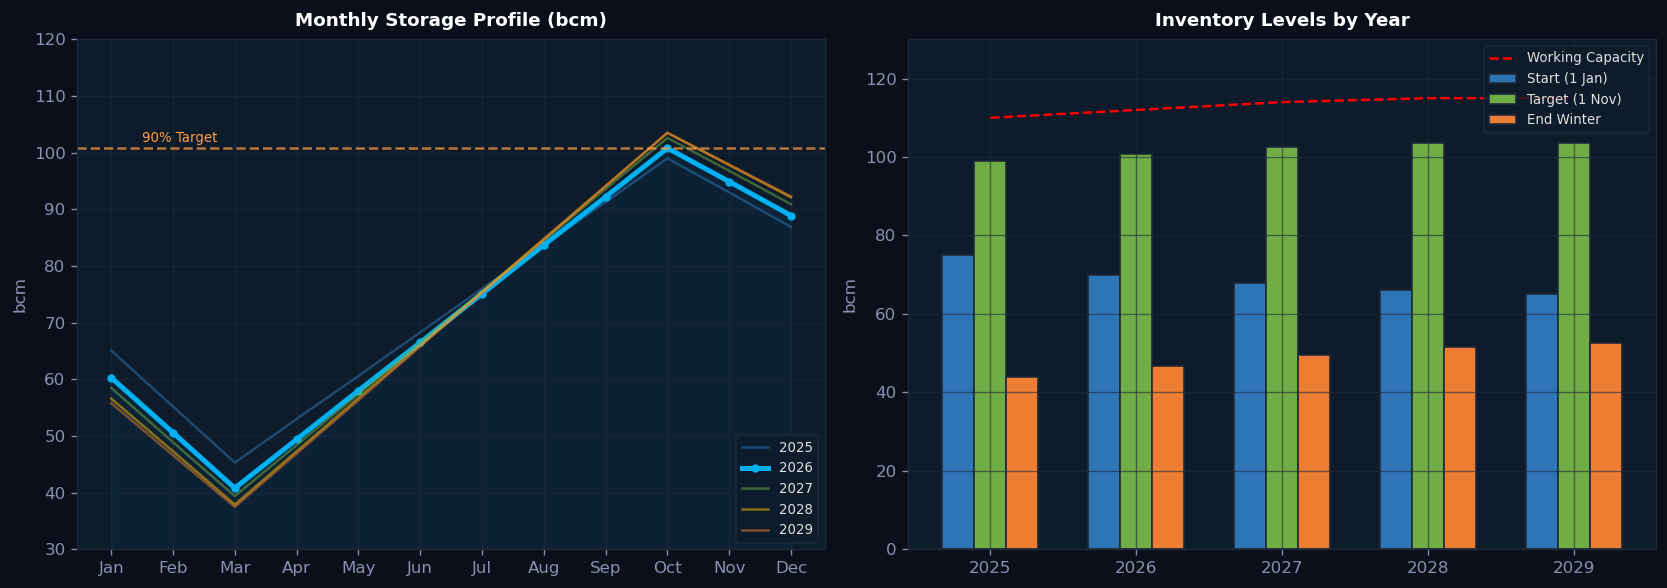

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly profiles
ax = axes[0]
yr_colors = ['#2E75B6','#00B0F0','#70AD47','#FFC000','#ED7D31']
for i, y in enumerate(YEARS):
    lw = 3 if i == 1 else 1.5
    alpha = 1.0 if i == 1 else 0.5
    ax.plot(MONTHS, storage_monthly[y], 'o-' if i==1 else '-', color=yr_colors[i],
            lw=lw, ms=4 if i==1 else 0, alpha=alpha, label=str(y))
ax.axhline(y=storage['Target Inventory'].iloc[1], color=C['accent'], ls='--', lw=1.5, alpha=0.7)
ax.text(0.5, storage['Target Inventory'].iloc[1]+1, '90% Target', fontsize=8, color=C['accent'])
ax.fill_between(range(12), 0, storage_monthly[2026], alpha=0.05, color=C['lng'])
ax.set_title('Monthly Storage Profile (bcm)', fontsize=11, fontweight='bold', color='white', pad=8)
ax.set_ylabel('bcm')
ax.set_ylim(30, 120)
ax.legend(fontsize=8, loc='lower right')

# Inventory bar comparison
ax = axes[1]
x = np.arange(5)
w = 0.22
ax.bar(x-w, storage['Start Inventory (1 Jan)'], w, color=C['norway'], label='Start (1 Jan)', edgecolor='#1e2a3a')
ax.bar(x, storage['Target Inventory'], w, color=C['positive'], label='Target (1 Nov)', edgecolor='#1e2a3a')
ax.bar(x+w, storage['End Winter Inventory'], w, color=C['algeria'], label='End Winter', edgecolor='#1e2a3a')
ax.plot(x, storage['Working Capacity'], 'r--', lw=1.5, label='Working Capacity')
ax.set_xticks(x)
ax.set_xticklabels(YEARS)
ax.set_title('Inventory Levels by Year', fontsize=11, fontweight='bold', color='white', pad=8)
ax.set_ylabel('bcm')
ax.set_ylim(0, 130)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Supply Stack Aggregation & Market Clearing

The merit-order supply stack ranks all sources by marginal cost. Norwegian pipeline gas (lowest cost) sits at the base; LNG (highest) is the price-setting marginal source. The intersection of the cumulative supply curve with demand gives the implied TTF clearing price.

In [ ]:
# ── SUPPLY STACK ───────────────────────────────────────────
stack_sources = pd.DataFrame({
    'Norwegian Pipeline': norway_net.values,
    'Indigenous EU': indigenous_total.values,
    'Russian Pipeline': pipeline_by_source['Russia'].values,
    'Algerian Pipeline': pipeline_by_source['Algeria'].values,
    'Azerbaijani Pipeline': pipeline_by_source['Azerbaijan'].values,
    'Libyan Pipeline': pipeline_by_source['Libya'].values,
    'Storage Withdrawal': storage['Winter Withdrawal'].values,
    'LNG (Marginal)': lng_max_deliverable.values,
}, index=YEARS)

stack_costs = pd.DataFrame({
    'Norwegian Pipeline': norway_marginal_cost,
    'Indigenous EU': indigenous_cost,
    'Russian Pipeline': [20.0]*5,
    'Algerian Pipeline': [22.0,21.0,20.0,19.5,19.0],
    'Azerbaijani Pipeline': [24.0,23.5,23.0,22.5,22.0],
    'Libyan Pipeline': [22.0]*5,
    'Storage Withdrawal': storage_cost,
    'LNG (Marginal)': lng_marginal_cost,
}, index=YEARS)

stack_colors = {
    'Norwegian Pipeline': C['norway'], 'Indigenous EU': C['indigenous'],
    'Russian Pipeline': C['russia'], 'Algerian Pipeline': C['algeria'],
    'Azerbaijani Pipeline': C['azerbaijan'], 'Libyan Pipeline': C['libya'],
    'Storage Withdrawal': C['storage'], 'LNG (Marginal)': C['lng'],
}

total_supply = stack_sources.sum(axis=1)
total_demand = assumptions['Total Demand (bcm)']
surplus_deficit = total_supply - total_demand

# Implied clearing price
def calc_implied_ttf():
    prices = []
    for i in range(5):
        lng_mc = lng_marginal_cost[i]
        sd_adj = -surplus_deficit.iloc[i] * 0.15
        carbon = assumptions['EU ETS Carbon (EUR/tCO2)'].iloc[i] * 0.055
        seasonality = 5.0
        prices.append(round(lng_mc + sd_adj + carbon + seasonality, 1))
    return prices

implied_ttf = calc_implied_ttf()
implied_ttf_usd = [round(implied_ttf[i] * 0.293 * assumptions['EUR/USD'].iloc[i], 2) for i in range(5)]

clearing_summary = pd.DataFrame({
    'Total Supply (bcm)': total_supply,
    'Total Demand (bcm)': total_demand,
    'Surplus/(Deficit)': surplus_deficit,
    'Implied TTF (EUR/MWh)': implied_ttf,
    'Implied TTF (USD/MMBtu)': implied_ttf_usd,
}, index=YEARS)

print("Supply-Demand Balance & Implied Clearing Price")
print("="*70)
display(clearing_summary.style.format('{:.1f}').map(
    lambda v: 'color: #70AD47' if isinstance(v, (int,float)) and v > 0 else
              'color: #ff6b6b' if isinstance(v, (int,float)) and v < 0 else '',
    subset=['Surplus/(Deficit)']))

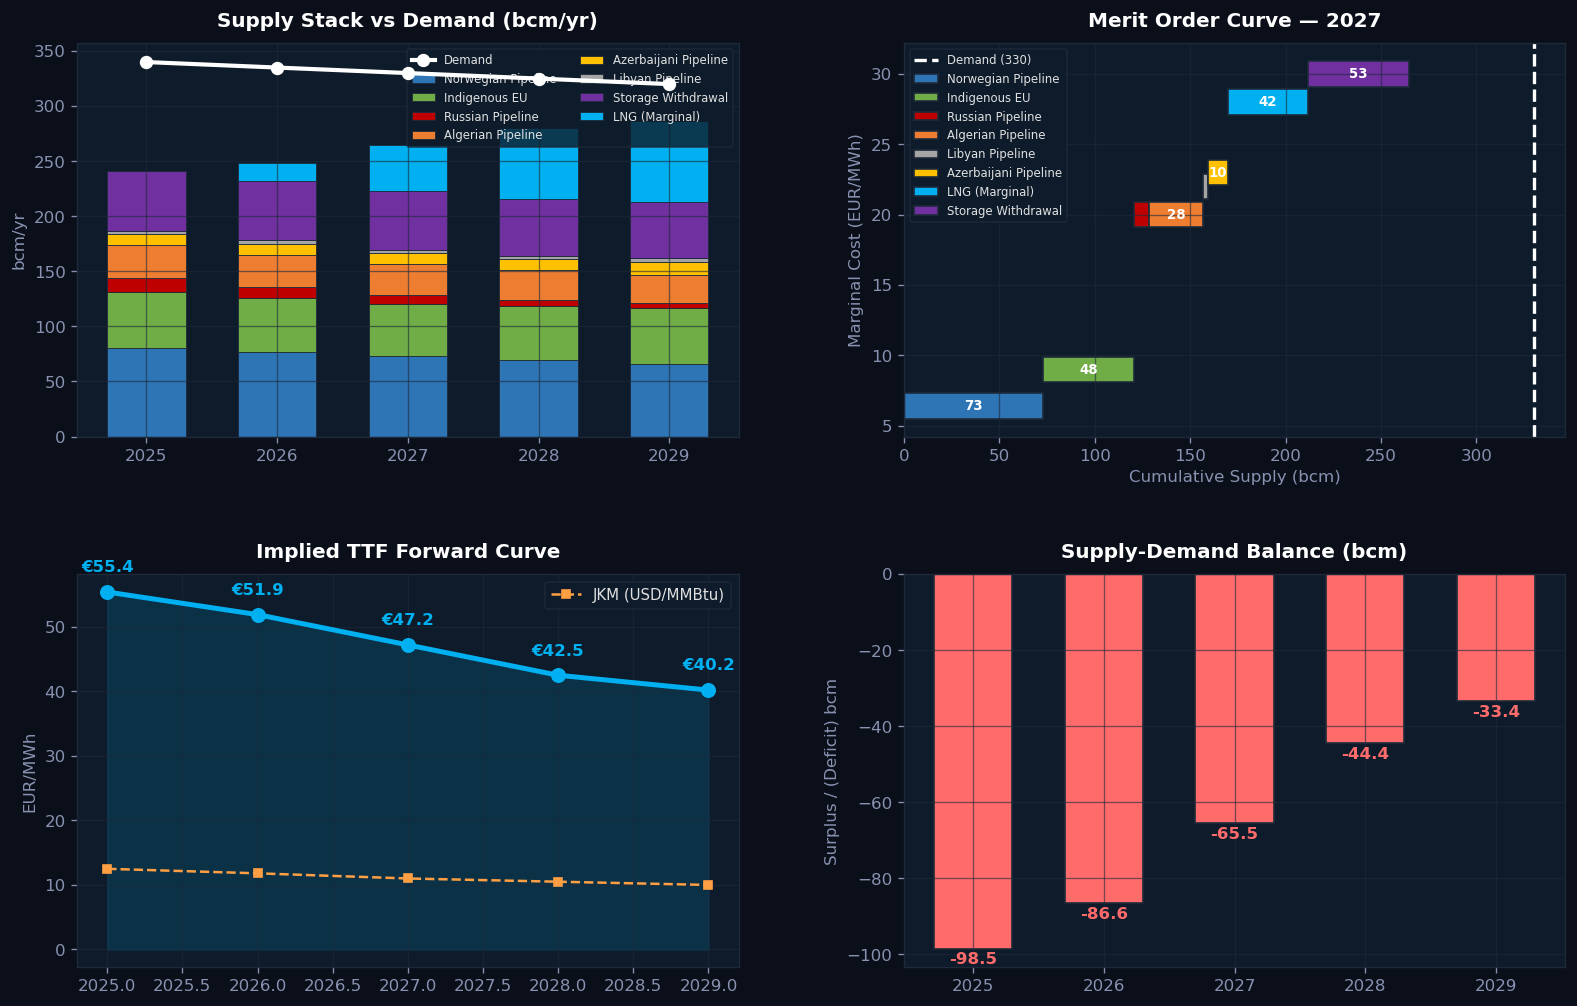

In [14]:
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.25)

# Stacked supply bar
ax1 = fig.add_subplot(gs[0, 0])
bottom = np.zeros(5)
for col in stack_sources.columns:
    ax1.bar(YEARS, stack_sources[col], bottom=bottom, color=stack_colors[col],
            label=col, width=0.6, edgecolor='#1e2a3a', linewidth=0.5)
    bottom += stack_sources[col].values
ax1.plot(YEARS, total_demand, 'wo-', ms=7, lw=2.5, label='Demand', zorder=10)
ax1.set_title('Supply Stack vs Demand (bcm/yr)', fontsize=12, fontweight='bold', color='white', pad=10)
ax1.set_ylabel('bcm/yr')
ax1.legend(fontsize=7, loc='upper right', ncol=2)

# Merit order curve for 2027
ax2 = fig.add_subplot(gs[0, 1])
yr = 2  # 2027
sorted_idx = stack_costs.iloc[yr].sort_values().index
cumulative = 0
for src in sorted_idx:
    vol = stack_sources[src].iloc[yr]
    cost = stack_costs[src].iloc[yr]
    if vol > 0:
        ax2.barh(y=cost, width=vol, left=cumulative, height=1.8,
                color=stack_colors[src], edgecolor='#1e2a3a', label=src)
        if vol > 8:
            ax2.text(cumulative + vol/2, cost, f'{vol:.0f}',
                    ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        cumulative += vol
ax2.axvline(x=total_demand.iloc[yr], color='white', ls='--', lw=2, label=f'Demand ({total_demand.iloc[yr]})')
ax2.set_title(f'Merit Order Curve — {YEARS[yr]}', fontsize=12, fontweight='bold', color='white', pad=10)
ax2.set_xlabel('Cumulative Supply (bcm)')
ax2.set_ylabel('Marginal Cost (EUR/MWh)')
ax2.legend(fontsize=7, loc='upper left')

# Implied TTF forward curve
ax3 = fig.add_subplot(gs[1, 0])
ax3.fill_between(YEARS, implied_ttf, alpha=0.15, color=C['lng'])
ax3.plot(YEARS, implied_ttf, 'o-', color=C['lng'], lw=3, ms=8, zorder=5)
for i, (y, p) in enumerate(zip(YEARS, implied_ttf)):
    ax3.annotate(f'€{p:.1f}', (y, p), textcoords="offset points",
                xytext=(0, 12), ha='center', fontsize=10, fontweight='bold', color=C['lng'])
ax3.plot(YEARS, assumptions['JKM (USD/MMBtu)'], 's--', color=C['accent'], lw=1.5, ms=5, label='JKM (USD/MMBtu)')
ax3.set_title('Implied TTF Forward Curve', fontsize=12, fontweight='bold', color='white', pad=10)
ax3.set_ylabel('EUR/MWh')
ax3.legend(fontsize=9)

# Supply-demand balance
ax4 = fig.add_subplot(gs[1, 1])
colors_sd = [C['positive'] if v >= 0 else C['negative'] for v in surplus_deficit]
ax4.bar(YEARS, surplus_deficit, color=colors_sd, edgecolor='#1e2a3a', width=0.6)
ax4.axhline(y=0, color='white', lw=0.5)
for y, v in zip(YEARS, surplus_deficit):
    ax4.text(y, v + (2 if v >= 0 else -4), f'{v:.1f}',
            ha='center', fontsize=10, fontweight='bold',
            color=C['positive'] if v >= 0 else C['negative'])
ax4.set_title('Supply-Demand Balance (bcm)', fontsize=12, fontweight='bold', color='white', pad=10)
ax4.set_ylabel('Surplus / (Deficit) bcm')

plt.show()

## 7. Scenario Analysis

Risk scenarios quantifying supply/demand impacts and TTF price sensitivity. Probability-weighted pricing gives an expected value that accounts for the asymmetric risk distribution.

In [ ]:
# ── SCENARIOS ──────────────────────────────────────────────
scenarios = pd.DataFrame({
    'Scenario': ['Base Case','Cold Winter','Mild Winter','Full Russian Cutoff',
                 'Asian LNG Surge','Major Norway Outage','Accelerated Renewables',
                 'US LNG Disruption','Qatar NFE Delay','Industrial Recovery'],
    'Supply Impact (bcm)': [0, 0, 0, -12, -20, -6, 0, -8, -20, 0],
    'Demand Impact (bcm)': [0, 25, -20, 0, 0, 0, -12, 0, 0, 15],
    'TTF Impact (EUR/MWh)': [0, 8, -6, 12, 10, 15, -4, 8, 5, 6],
    'Probability': [0.35, 0.10, 0.10, 0.07, 0.07, 0.03, 0.07, 0.05, 0.10, 0.06],
})

base_ttf = implied_ttf[0]
scenarios['Implied Price'] = base_ttf + scenarios['TTF Impact (EUR/MWh)']
prob_weighted = (scenarios['Implied Price'] * scenarios['Probability']).sum()

print(f"Base Case TTF (2025): €{base_ttf:.1f}/MWh")
print(f"Probability-Weighted TTF: €{prob_weighted:.1f}/MWh")
print(f"Range: €{scenarios['Implied Price'].min():.1f} — €{scenarios['Implied Price'].max():.1f}/MWh")
print()
display(scenarios.style.format({
    'Supply Impact (bcm)': '{:+.0f}', 'Demand Impact (bcm)': '{:+.0f}',
    'TTF Impact (EUR/MWh)': '{:+.1f}', 'Probability': '{:.0%}', 'Implied Price': '€{:.1f}'
}).map(lambda v: 'color: #ff6b6b' if isinstance(v,str) and v.startswith('€') and float(v[1:]) > base_ttf
            else 'color: #70AD47' if isinstance(v,str) and v.startswith('€') and float(v[1:]) < base_ttf
            else '', subset=['Implied Price']))

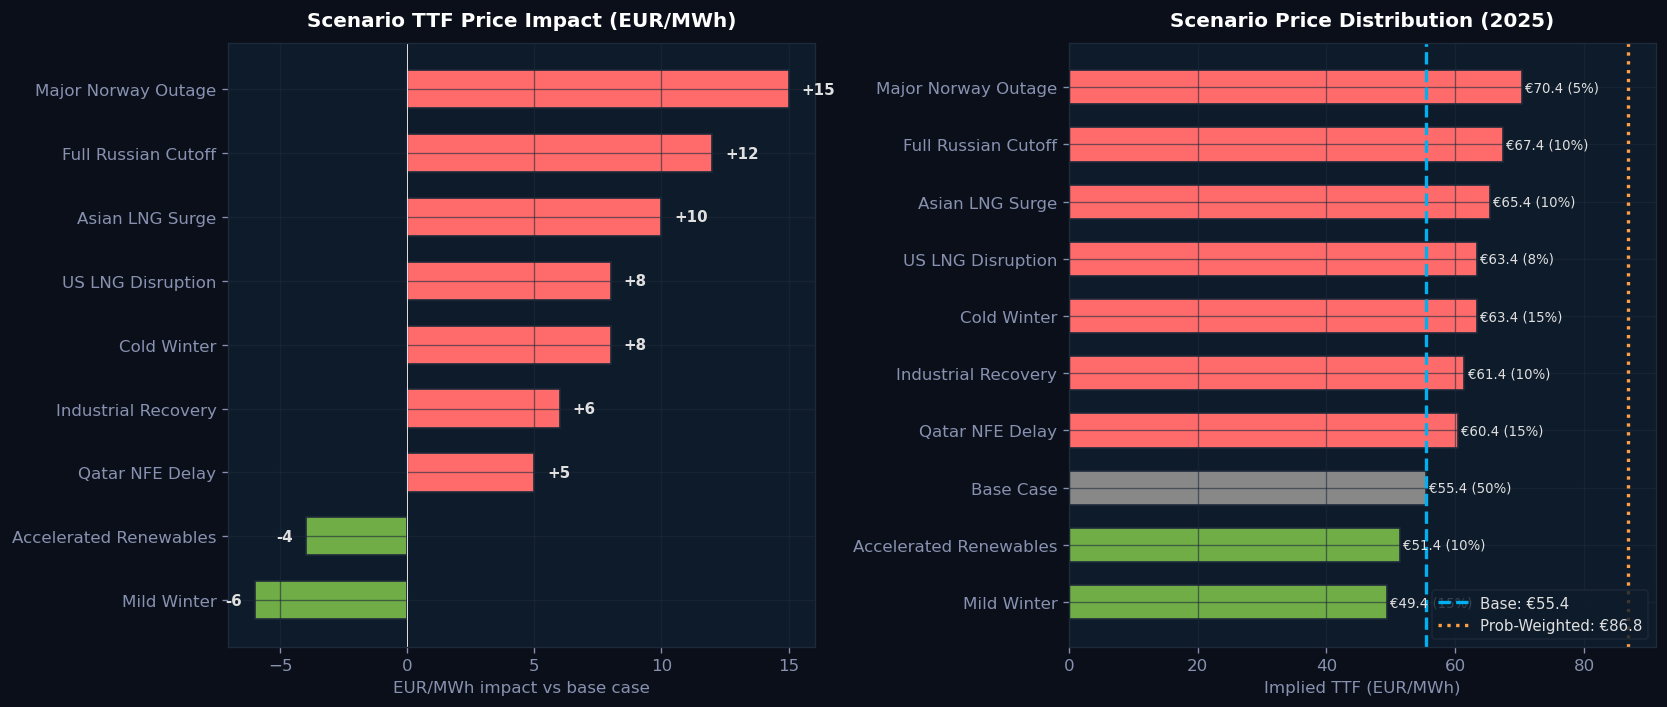

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Tornado / waterfall
ax = axes[0]
scen_sorted = scenarios[scenarios['Scenario']!='Base Case'].sort_values('TTF Impact (EUR/MWh)')
colors_s = [C['positive'] if v < 0 else C['negative'] for v in scen_sorted['TTF Impact (EUR/MWh)']]
bars = ax.barh(scen_sorted['Scenario'], scen_sorted['TTF Impact (EUR/MWh)'],
               color=colors_s, edgecolor='#1e2a3a', height=0.6)
ax.axvline(x=0, color='white', lw=0.5)
for bar, val in zip(bars, scen_sorted['TTF Impact (EUR/MWh)']):
    x = bar.get_width()
    ax.text(x + (0.5 if x >= 0 else -0.5), bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}', va='center', ha='left' if x >= 0 else 'right',
            fontsize=9, color='#e0e0e0', fontweight='bold')
ax.set_title('Scenario TTF Price Impact (EUR/MWh)', fontsize=12, fontweight='bold', color='white', pad=10)
ax.set_xlabel('EUR/MWh impact vs base case')

# Price distribution
ax = axes[1]
scen_all = scenarios.sort_values('Implied Price')
colors_p = [C['positive'] if p < base_ttf else '#888' if p == base_ttf else C['negative']
            for p in scen_all['Implied Price']]
bars = ax.barh(scen_all['Scenario'], scen_all['Implied Price'],
               color=colors_p, edgecolor='#1e2a3a', height=0.6)
ax.axvline(x=base_ttf, color=C['lng'], ls='--', lw=2, label=f'Base: €{base_ttf:.1f}')
ax.axvline(x=prob_weighted, color=C['accent'], ls=':', lw=2, label=f'Prob-Weighted: €{prob_weighted:.1f}')
for bar, (_, row) in zip(bars, scen_all.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'€{row["Implied Price"]:.1f} ({row["Probability"]:.0%})',
            va='center', fontsize=8, color='#e0e0e0')
ax.set_title('Scenario Price Distribution (2025)', fontsize=12, fontweight='bold', color='white', pad=10)
ax.set_xlabel('Implied TTF (EUR/MWh)')
ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

## 8. Sensitivity Analysis

Price elasticity of TTF to unit changes in each key driver. These sensitivities are approximate and non-linear — they interact (e.g., a cold winter simultaneously increases demand and draws down storage, amplifying the price impact).

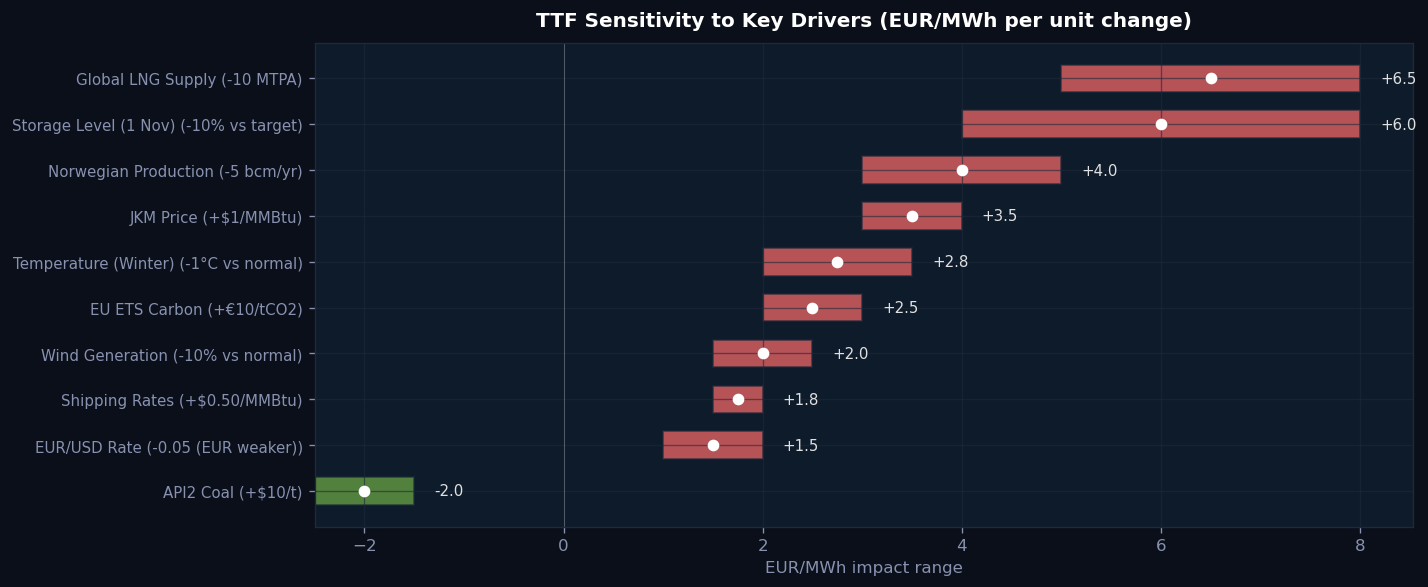

,Driver,Unit Change,TTF Low (EUR/MWh),TTF High (EUR/MWh),Direction,Confidence
0,JKM Price,+$1/MMBtu,3.000000,4.000000,↑,High
1,EU ETS Carbon,+€10/tCO2,2.000000,3.000000,↑,High
2,API2 Coal,+$10/t,-2.500000,-1.500000,↓ (switch),Medium
3,Norwegian Production,-5 bcm/yr,3.000000,5.000000,↑,High
4,Temperature (Winter),-1°C vs normal,2.000000,3.500000,↑,Medium
5,Wind Generation,-10% vs normal,1.500000,2.500000,↑,Medium
6,EUR/USD Rate,-0.05 (EUR weaker),1.000000,2.000000,↑ (LNG cost),Medium
7,Storage Level (1 Nov),-10% vs target,4.000000,8.000000,↑,High
8,Global LNG Supply,-10 MTPA,5.000000,8.000000,↑,High
9,Shipping Rates,+$0.50/MMBtu,1.500000,2.000000,↑,Medium


In [17]:
# ── SENSITIVITY TABLE ──────────────────────────────────────
sensitivity = pd.DataFrame({
    'Driver': ['JKM Price','EU ETS Carbon','API2 Coal','Norwegian Production',
               'Temperature (Winter)','Wind Generation','EUR/USD Rate',
               'Storage Level (1 Nov)','Global LNG Supply','Shipping Rates'],
    'Unit Change': ['+$1/MMBtu','+€10/tCO2','+$10/t','-5 bcm/yr',
                    '-1°C vs normal','-10% vs normal','-0.05 (EUR weaker)',
                    '-10% vs target','-10 MTPA','+$0.50/MMBtu'],
    'TTF Low (EUR/MWh)': [3.0, 2.0, -2.5, 3.0, 2.0, 1.5, 1.0, 4.0, 5.0, 1.5],
    'TTF High (EUR/MWh)': [4.0, 3.0, -1.5, 5.0, 3.5, 2.5, 2.0, 8.0, 8.0, 2.0],
    'Direction': ['↑','↑','↓ (switch)','↑','↑','↑','↑ (LNG cost)','↑','↑','↑'],
    'Confidence': ['High','High','Medium','High','Medium','Medium','Medium','High','High','Medium'],
})
sensitivity['Midpoint'] = (sensitivity['TTF Low (EUR/MWh)'] + sensitivity['TTF High (EUR/MWh)']) / 2

fig, ax = plt.subplots(figsize=(12, 5))
sens_sorted = sensitivity.sort_values('Midpoint', ascending=True)
y = np.arange(len(sens_sorted))
low = sens_sorted['TTF Low (EUR/MWh)'].values
high = sens_sorted['TTF High (EUR/MWh)'].values
mid = sens_sorted['Midpoint'].values

for i in range(len(sens_sorted)):
    color = C['negative'] if mid[i] > 0 else C['positive']
    ax.barh(y[i], high[i]-low[i], left=low[i], color=color, alpha=0.7,
            edgecolor='#1e2a3a', height=0.6)
    ax.plot(mid[i], y[i], 'wo', ms=6, zorder=5)
    ax.text(high[i]+0.2, y[i], f'{mid[i]:+.1f}', va='center', fontsize=9, color='#e0e0e0')

ax.set_yticks(y)
ax.set_yticklabels([f"{r['Driver']} ({r['Unit Change']})" for _,r in sens_sorted.iterrows()], fontsize=9)
ax.axvline(x=0, color='white', lw=0.5, alpha=0.3)
ax.set_title('TTF Sensitivity to Key Drivers (EUR/MWh per unit change)',
             fontsize=12, fontweight='bold', color='white', pad=10)
ax.set_xlabel('EUR/MWh impact range')
plt.tight_layout()
plt.show()

print()
display(sensitivity[['Driver','Unit Change','TTF Low (EUR/MWh)','TTF High (EUR/MWh)',
                     'Direction','Confidence']].style.set_properties(**{'text-align':'center'}))

## 9. Executive Summary Dashboard

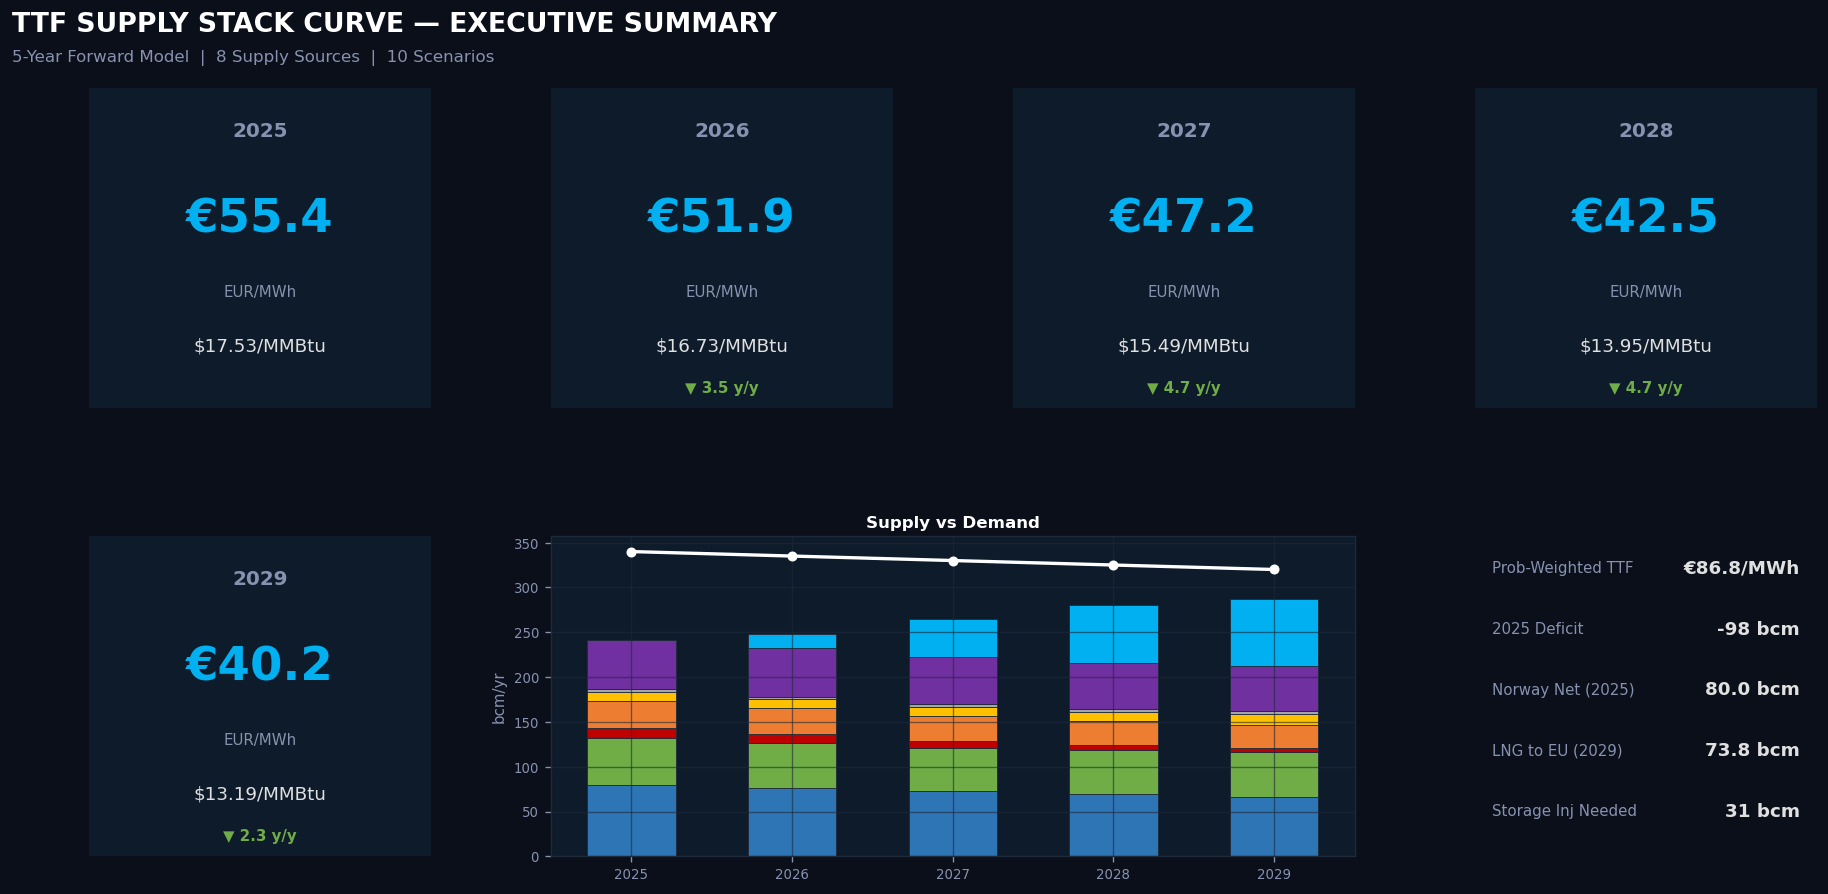


✓ Model complete


In [18]:
fig = plt.figure(figsize=(16, 8))
fig.patch.set_facecolor('#0a0f1a')

# Title bar
fig.text(0.02, 0.96, 'TTF SUPPLY STACK CURVE — EXECUTIVE SUMMARY', fontsize=16,
         fontweight='bold', color='white', va='top')
fig.text(0.02, 0.92, f'5-Year Forward Model  |  {len(stack_sources.columns)} Supply Sources  |  {len(scenarios)} Scenarios',
         fontsize=10, color='#8892b0', va='top')

gs = GridSpec(2, 4, figure=fig, top=0.88, bottom=0.08, left=0.06, right=0.96, hspace=0.4, wspace=0.35)

# Price cards
for i, y in enumerate(YEARS):
    ax = fig.add_subplot(gs[0, i] if i < 4 else gs[1, i-4])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_facecolor('#0d1b2a')
    rect = FancyBboxPatch((0.02,0.02), 0.96, 0.96, boxstyle="round,pad=0.05",
                          facecolor='#0d1b2a', edgecolor='#1e2a3a', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(0.5, 0.85, str(y), ha='center', fontsize=12, color='#8892b0', fontweight='bold')
    ax.text(0.5, 0.55, f'€{implied_ttf[i]:.1f}', ha='center', fontsize=28, color=C['lng'], fontweight='bold')
    ax.text(0.5, 0.35, 'EUR/MWh', ha='center', fontsize=9, color='#8892b0')
    ax.text(0.5, 0.18, f'${implied_ttf_usd[i]:.2f}/MMBtu', ha='center', fontsize=11, color='#e0e0e0')
    if i > 0:
        delta = implied_ttf[i] - implied_ttf[i-1]
        color = C['positive'] if delta < 0 else C['negative']
        arrow = '▼' if delta < 0 else '▲'
        ax.text(0.5, 0.05, f'{arrow} {abs(delta):.1f} y/y', ha='center', fontsize=9,
                color=color, fontweight='bold')

if len(YEARS) > 4:
    ax = fig.add_subplot(gs[1, 0])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    ax.set_facecolor('#0d1b2a')
    rect = FancyBboxPatch((0.02,0.02), 0.96, 0.96, boxstyle="round,pad=0.05",
                          facecolor='#0d1b2a', edgecolor='#1e2a3a', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(0.5, 0.85, str(YEARS[4]), ha='center', fontsize=12, color='#8892b0', fontweight='bold')
    ax.text(0.5, 0.55, f'€{implied_ttf[4]:.1f}', ha='center', fontsize=28, color=C['lng'], fontweight='bold')
    ax.text(0.5, 0.35, 'EUR/MWh', ha='center', fontsize=9, color='#8892b0')
    ax.text(0.5, 0.18, f'${implied_ttf_usd[4]:.2f}/MMBtu', ha='center', fontsize=11, color='#e0e0e0')
    delta = implied_ttf[4] - implied_ttf[3]
    color = C['positive'] if delta < 0 else C['negative']
    arrow = '▼' if delta < 0 else '▲'
    ax.text(0.5, 0.05, f'{arrow} {abs(delta):.1f} y/y', ha='center', fontsize=9, color=color, fontweight='bold')

# Supply stack mini
ax5 = fig.add_subplot(gs[1, 1:3])
bottom = np.zeros(5)
for col in stack_sources.columns:
    ax5.bar(YEARS, stack_sources[col], bottom=bottom, color=stack_colors[col],
            width=0.55, edgecolor='#1e2a3a', linewidth=0.5)
    bottom += stack_sources[col].values
ax5.plot(YEARS, total_demand, 'wo-', ms=5, lw=2, zorder=10)
ax5.set_title('Supply vs Demand', fontsize=10, fontweight='bold', color='white', pad=5)
ax5.set_ylabel('bcm/yr', fontsize=9)
ax5.tick_params(labelsize=8)

# Key metrics
ax6 = fig.add_subplot(gs[1, 3])
ax6.axis('off')
ax6.set_facecolor('#0d1b2a')
metrics = [
    ('Prob-Weighted TTF', f'€{prob_weighted:.1f}/MWh'),
    ('2025 Deficit', f'{surplus_deficit.iloc[0]:.0f} bcm'),
    ('Norway Net (2025)', f'{norway_net.iloc[0]:.1f} bcm'),
    ('LNG to EU (2029)', f'{lng_max_deliverable.iloc[4]:.1f} bcm'),
    ('Storage Inj Needed', f'{storage["Required Injection"].iloc[1]:.0f} bcm'),
]
for i, (label, val) in enumerate(metrics):
    yp = 0.9 - i * 0.19
    ax6.text(0.05, yp, label, fontsize=9, color='#8892b0', va='center')
    ax6.text(0.95, yp, val, fontsize=11, color='#e0e0e0', fontweight='bold', va='center', ha='right')

plt.show()
print("\n✓ Model complete")